# Cross-Dataset Validation — Random Forest: Chapman-Shaoxing → PTB-XL

**Goal:** Test the RF model trained on Chapman-Shaoxing on PTB-XL.

**Training data:** Chapman-Shaoxing (132 morphological features, 12 leads)  
**Test data:** PTB-XL (12 leads, 500 Hz, 10s)

No training — feature extraction + inference only using saved RF model.


In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install wfdb neurokit2 -q
print('Ready.')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 140.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
Ready.


## 1. Imports

In [2]:
import os
import numpy as np
import neurokit2 as nk
import pickle
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, matthews_corrcoef,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import wfdb

print("Imports done.")

Imports done.


## 2. Configuration

In [3]:
class Config:
    afib_dir = ""
    normal_dir = ""
    model_path = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_rf_morph_all_leads_model.pkl"
    feature_names_path = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/rf_morph_all_leads_feature_names.pkl"

    fs = 500
    num_channels = 12
    recording_seconds = 10
    recording_samples = fs * recording_seconds
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    pdf_dir = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/plots_pdf_rf_cross_ptbxl"

config = Config()
assert os.path.exists(config.model_path), "RF model not found"
os.makedirs(config.pdf_dir, exist_ok=True)
print("Config ready.")

Config ready.


## 3. Unzip PTB-XL Data

In [4]:
import os

if not os.path.exists("/content/ptbxl_data"):
    print("Unzipping PTB-XL...")
    !unzip -q "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/ptbxl_afib_normal_subset.zip" -d /content/ptbxl_data/
    print("Done!")

for base in ["/content/ptbxl_data", "/content/ptbxl_data/ptbxl_afib_normal_subset"]:
    if os.path.exists(os.path.join(base, "afib")):
        config.afib_dir = os.path.join(base, "afib")
        config.normal_dir = os.path.join(base, "normal")
        break

print(f"AFib: {len([f for f in os.listdir(config.afib_dir) if f.endswith('.hea')])} records")
print(f"Normal: {len([f for f in os.listdir(config.normal_dir) if f.endswith('.hea')])} records")

Unzipping PTB-XL...
Done!
AFib: 1477 records
Normal: 9477 records


## 4. Load Trained RF Model

In [5]:
with open(config.model_path, 'rb') as f:
    rf_model = pickle.load(f)
with open(config.feature_names_path, 'rb') as f:
    feature_names = pickle.load(f)

print(f"RF model loaded: {config.model_path}")
print(f"Features: {len(feature_names)}")
print(f"Trees: {rf_model.n_estimators}")

RF model loaded: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_rf_morph_all_leads_model.pkl
Features: 132
Trees: 500


## 5. Discover PTB-XL Records

In [6]:
afib_files = sorted([f[:-4] for f in os.listdir(config.afib_dir) if f.endswith('.hea')])
normal_files = sorted([f[:-4] for f in os.listdir(config.normal_dir) if f.endswith('.hea')])

all_records = []
for name in afib_files:
    all_records.append({"path": os.path.join(config.afib_dir, name), "name": name, "label": 1})
for name in normal_files:
    all_records.append({"path": os.path.join(config.normal_dir, name), "name": name, "label": 0})

print(f"PTB-XL Subset:")
print(f"  AFib: {len(afib_files)}, Normal: {len(normal_files)}, Total: {len(all_records)}")
print(f"  AFib prevalence: {len(afib_files)/len(all_records):.2%}")

PTB-XL Subset:
  AFib: 1477, Normal: 9477, Total: 10954
  AFib prevalence: 13.48%


## 6. Feature Extraction Functions

In [7]:
def extract_features_single_lead(signal_1lead, fs):
    try:
        signals, info = nk.ecg_process(signal_1lead, sampling_rate=fs)
        r_peaks = info["ECG_R_Peaks"]
        n_beats = len(r_peaks)
        if n_beats < 3:
            return None

        r_amplitudes = signals["ECG_Clean"].values[r_peaks]
        mean_r_amplitude = np.mean(r_amplitudes)

        rr_intervals = np.diff(r_peaks) / fs
        mean_rr = np.mean(rr_intervals)
        heart_rate = 60.0 / mean_rr if mean_rr > 0 else 0

        p_peak_indices = np.where(signals["ECG_P_Peaks"].values == 1)[0]
        p_onset_indices = np.where(signals["ECG_P_Onsets"].values == 1)[0]
        p_offset_indices = np.where(signals["ECG_P_Offsets"].values == 1)[0]

        p_detected = 0
        for rp in r_peaks:
            ws = rp - int(0.3 * fs)
            we = rp - int(0.05 * fs)
            if ws >= 0 and np.any((p_peak_indices >= ws) & (p_peak_indices <= we)):
                p_detected += 1
        p_wave_ratio = p_detected / n_beats

        mean_p_amplitude = np.mean(signals["ECG_Clean"].values[p_peak_indices]) if len(p_peak_indices) > 0 else 0.0

        p_durs = []
        for onset in p_onset_indices:
            offs = p_offset_indices[p_offset_indices > onset]
            if len(offs) > 0:
                d = (offs[0] - onset) / fs * 1000
                if 20 < d < 200: p_durs.append(d)
        mean_p_duration = np.mean(p_durs) if p_durs else 0.0

        r_onset_indices = np.where(signals["ECG_R_Onsets"].values == 1)[0]
        r_offset_indices = np.where(signals["ECG_R_Offsets"].values == 1)[0]
        qrs_durs = []
        for onset in r_onset_indices:
            offs = r_offset_indices[r_offset_indices > onset]
            if len(offs) > 0:
                d = (offs[0] - onset) / fs * 1000
                if 40 < d < 200: qrs_durs.append(d)
        mean_qrs_duration = np.mean(qrs_durs) if qrs_durs else 0.0

        t_peak_indices = np.where(signals["ECG_T_Peaks"].values == 1)[0]
        mean_t_amplitude = np.mean(signals["ECG_Clean"].values[t_peak_indices]) if len(t_peak_indices) > 0 else 0.0

        pr_ints = []
        for rp in r_peaks:
            ws = rp - int(0.3 * fs)
            if ws < 0: continue
            p_before = p_onset_indices[(p_onset_indices >= ws) & (p_onset_indices < rp)]
            if len(p_before) > 0:
                pr = (rp - p_before[-1]) / fs * 1000
                if 80 < pr < 350: pr_ints.append(pr)
        mean_pr = np.mean(pr_ints) if pr_ints else 0.0

        t_offset_indices = np.where(signals["ECG_T_Offsets"].values == 1)[0]
        qt_ints = []
        for onset in r_onset_indices:
            t_offs = t_offset_indices[t_offset_indices > onset]
            if len(t_offs) > 0:
                qt = (t_offs[0] - onset) / fs * 1000
                if 200 < qt < 600: qt_ints.append(qt)
        mean_qt = np.mean(qt_ints) if qt_ints else 0.0

        return [p_wave_ratio, mean_p_amplitude, mean_p_duration,
                mean_qrs_duration, mean_r_amplitude, mean_t_amplitude,
                mean_pr, mean_qt, mean_rr, heart_rate, n_beats]
    except:
        return None

def extract_features_all_leads(signal, fs, config):
    all_features = []
    for ch in range(config.num_channels):
        lead_features = extract_features_single_lead(signal[:, ch], fs)
        if lead_features is None:
            all_features.extend([0.0] * 11)
        else:
            all_features.extend(lead_features)
    features = np.array(all_features, dtype=np.float32)
    if np.any(np.isnan(features)) or np.any(np.isinf(features)):
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    return features

print("Feature extraction functions defined.")

Feature extraction functions defined.


## 7. Extract Features from PTB-XL

In [8]:
print(f"Extracting features from {len(all_records)} records (12 leads each)...")
start_time = time.time()

all_features = []
all_labels = []
skipped = 0

for i, rec in enumerate(all_records):
    if (i + 1) % 500 == 0:
        elapsed = time.time() - start_time
        pct = (i + 1) / len(all_records) * 100
        est_remaining = (elapsed / (i + 1) * len(all_records)) - elapsed
        print(f"  Processed {i+1}/{len(all_records)} ({pct:.0f}%) [{elapsed/60:.1f} min, ~{est_remaining/60:.0f} min remaining]")

    try:
        record = wfdb.rdrecord(rec["path"])
        signal = record.p_signal

        if signal.shape[1] < config.num_channels or np.any(np.isnan(signal)):
            skipped += 1
            continue

        if len(signal) < config.recording_samples:
            signal = np.vstack([signal, np.zeros((config.recording_samples - len(signal), config.num_channels))])
        elif len(signal) > config.recording_samples:
            signal = signal[:config.recording_samples, :]

        features = extract_features_all_leads(signal, config.fs, config)
        all_features.append(features)
        all_labels.append(rec["label"])
    except:
        skipped += 1

all_features = np.array(all_features, dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.int64)

load_time = time.time() - start_time
loaded_afib = np.sum(all_labels == 1)
loaded_normal = np.sum(all_labels == 0)
print(f"\nExtraction complete in {load_time/60:.1f} minutes")
print(f"Records loaded: {len(all_labels)} (skipped: {skipped})")
print(f"  AFib: {loaded_afib}, Normal: {loaded_normal}")
print(f"  Features per record: {all_features.shape[1]}")

Extracting features from 10954 records (12 leads each)...
  Processed 500/10954 (5%) [13.9 min, ~290 min remaining]
  Processed 1000/10954 (9%) [27.8 min, ~276 min remaining]
  Processed 1500/10954 (14%) [41.5 min, ~261 min remaining]
  Processed 2000/10954 (18%) [54.2 min, ~242 min remaining]
  Processed 2500/10954 (23%) [67.0 min, ~227 min remaining]
  Processed 3000/10954 (27%) [79.8 min, ~212 min remaining]
  Processed 3500/10954 (32%) [92.6 min, ~197 min remaining]
  Processed 4000/10954 (37%) [105.5 min, ~183 min remaining]
  Processed 4500/10954 (41%) [118.2 min, ~170 min remaining]
  Processed 5000/10954 (46%) [131.2 min, ~156 min remaining]
  Processed 5500/10954 (50%) [144.0 min, ~143 min remaining]
  Processed 6000/10954 (55%) [156.9 min, ~130 min remaining]
  Processed 6500/10954 (59%) [169.8 min, ~116 min remaining]
  Processed 7000/10954 (64%) [182.8 min, ~103 min remaining]
  Processed 7500/10954 (68%) [195.7 min, ~90 min remaining]
  Processed 8000/10954 (73%) [208.7 mi

## 8. Run Inference

In [9]:
print(f"Running RF inference on {len(all_labels)} samples...")

all_preds = rf_model.predict(all_features)
all_probs = rf_model.predict_proba(all_features)[:, 1]
all_targets = all_labels

print("Inference complete.")

Running RF inference on 10954 samples...
Inference complete.


## 9. Compute All Metrics

In [10]:
cm = confusion_matrix(all_targets, all_preds, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(all_targets, all_preds)
prec = precision_score(all_targets, all_preds, pos_label=1, zero_division=0)
rec = recall_score(all_targets, all_preds, pos_label=1, zero_division=0)
f1 = f1_score(all_targets, all_preds, pos_label=1, zero_division=0)
mcc = matthews_corrcoef(all_targets, all_preds)
auroc = roc_auc_score(all_targets, all_probs)
auprc = average_precision_score(all_targets, all_probs)
brier = brier_score_loss(all_targets, all_probs)

n_bins = 10
bin_boundaries = np.linspace(0, 1, n_bins + 1)
ece, mce = 0.0, 0.0
for i in range(n_bins):
    mask = (all_probs >= bin_boundaries[i]) & (all_probs < bin_boundaries[i+1]) if i < n_bins-1 else (all_probs >= bin_boundaries[i]) & (all_probs <= bin_boundaries[i+1])
    bc = mask.sum()
    if bc > 0:
        err = abs(all_targets[mask].mean() - all_probs[mask].mean())
        ece += (bc / len(all_targets)) * err
        mce = max(mce, err)

print("=" * 65)
print("CROSS-DATASET VALIDATION RESULTS (Random Forest)")
print("Trained on: Chapman-Shaoxing | Tested on: PTB-XL")
print("=" * 65)
print(f"  Accuracy:   {acc:.4f}")
print(f"  Precision:  {prec:.4f}")
print(f"  Recall:     {rec:.4f}")
print(f"  F1:         {f1:.4f}")
print(f"  MCC:        {mcc:.4f}")
print(f"  AUROC:      {auroc:.4f}")
print(f"  AUPRC:      {auprc:.4f}")
print(f"  Brier:      {brier:.4f}")
print(f"  ECE:        {ece:.4f}")
print(f"  MCE:        {mce:.4f}")
print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print()
print(classification_report(all_targets, all_preds, target_names=["Normal", "AFib"]))

CROSS-DATASET VALIDATION RESULTS (Random Forest)
Trained on: Chapman-Shaoxing | Tested on: PTB-XL
  Accuracy:   0.9400
  Precision:  0.8475
  Recall:     0.6770
  F1:         0.7527
  MCC:        0.7250
  AUROC:      0.9713
  AUPRC:      0.8623
  Brier:      0.0501
  ECE:        0.0615
  MCE:        0.2038
  TN=9297  FP=180  FN=477  TP=1000

              precision    recall  f1-score   support

      Normal       0.95      0.98      0.97      9477
        AFib       0.85      0.68      0.75      1477

    accuracy                           0.94     10954
   macro avg       0.90      0.83      0.86     10954
weighted avg       0.94      0.94      0.94     10954



## 10. Confusion Matrix

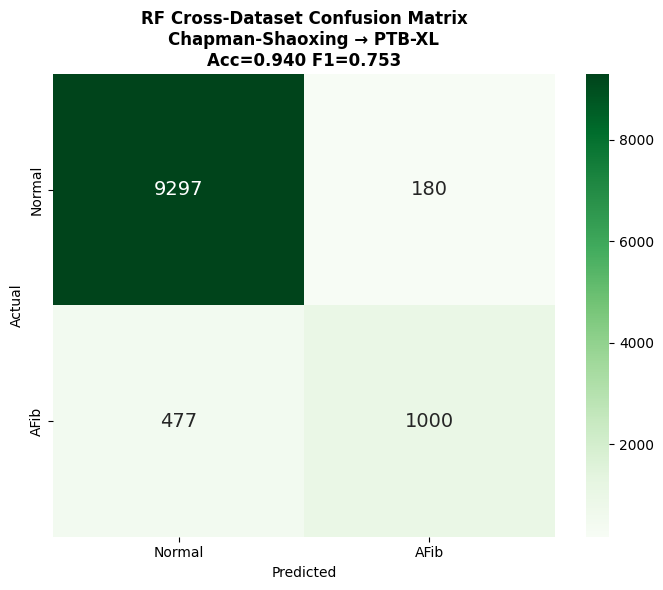

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Normal", "AFib"], yticklabels=["Normal", "AFib"],
            ax=ax, annot_kws={"size": 14})
ax.set_title(f"RF Cross-Dataset Confusion Matrix\nChapman-Shaoxing → PTB-XL\nAcc={acc:.3f} F1={f1:.3f}", fontsize=12, fontweight='bold')
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "ptbxl_rf_confusion_matrix.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 11. ROC Curve

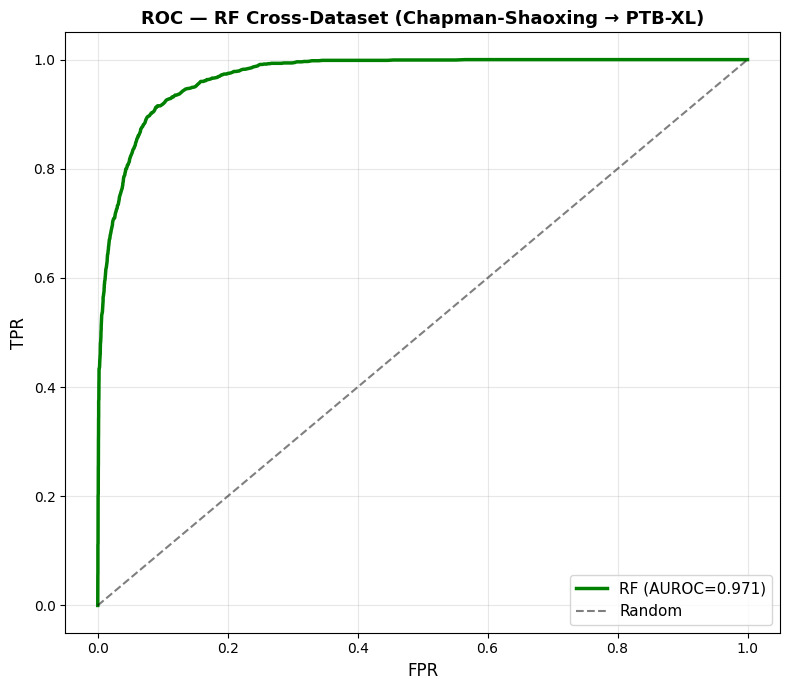

In [12]:
fig, ax = plt.subplots(figsize=(8, 7))
fpr, tpr, _ = roc_curve(all_targets, all_probs)
ax.plot(fpr, tpr, color='green', linewidth=2.5, label=f'RF (AUROC={auroc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('FPR', fontsize=12); ax.set_ylabel('TPR', fontsize=12)
ax.set_title('ROC — RF Cross-Dataset (Chapman-Shaoxing → PTB-XL)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "ptbxl_rf_roc.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 12. Precision-Recall Curve

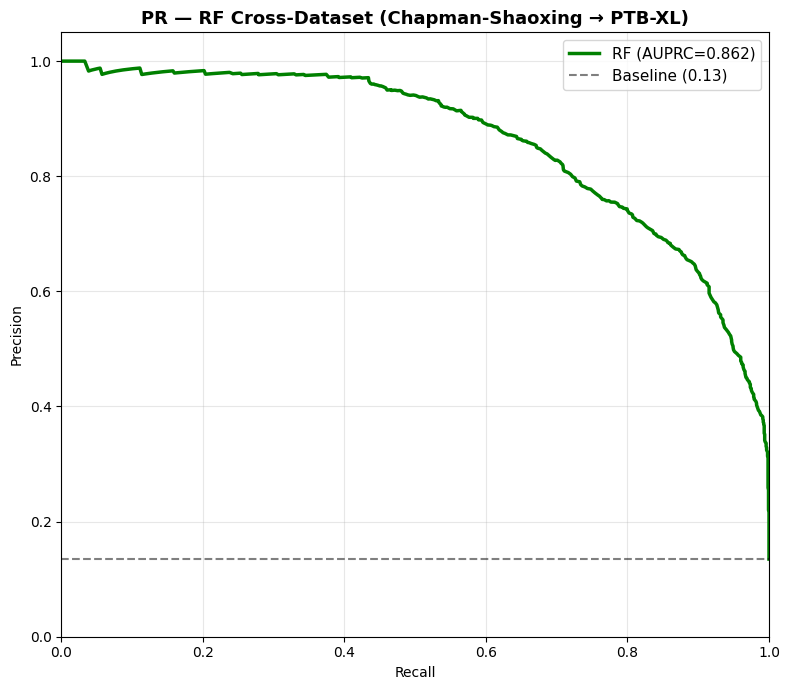

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
prec_c, rec_c, _ = precision_recall_curve(all_targets, all_probs)
ax.plot(rec_c, prec_c, color='green', linewidth=2.5, label=f'RF (AUPRC={auprc:.3f})')
baseline = np.mean(all_targets)
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR — RF Cross-Dataset (Chapman-Shaoxing → PTB-XL)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11); ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "ptbxl_rf_pr.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 13. Calibration Plot

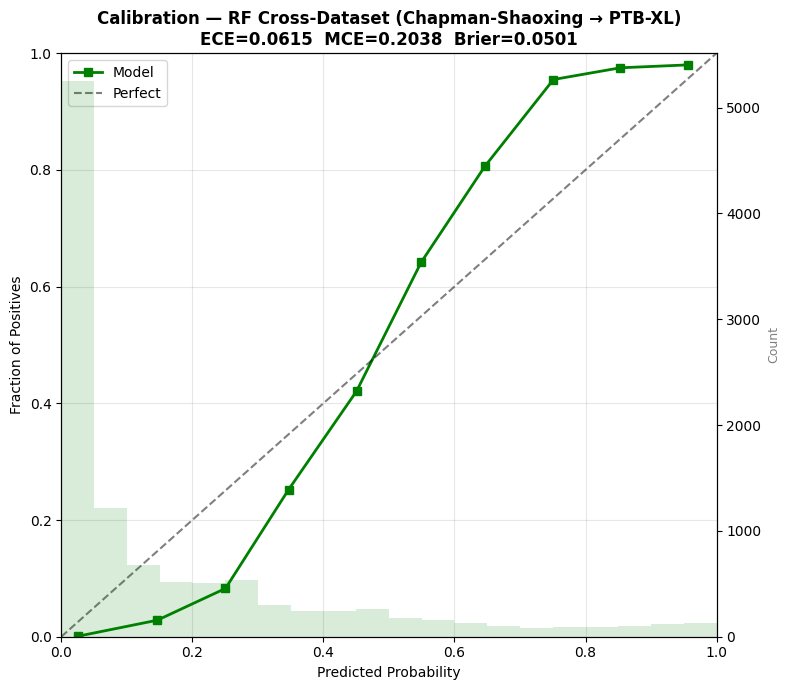

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
fraction_pos, mean_predicted = calibration_curve(all_targets, all_probs, n_bins=10, strategy='uniform')
ax.plot(mean_predicted, fraction_pos, 's-', color='green', linewidth=2, markersize=6, label='Model')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
ax2 = ax.twinx()
ax2.hist(all_probs, bins=20, range=(0, 1), alpha=0.15, color='green')
ax2.set_ylabel('Count', fontsize=9, alpha=0.5)
ax.set_title(f"Calibration — RF Cross-Dataset (Chapman-Shaoxing → PTB-XL)\nECE={ece:.4f}  MCE={mce:.4f}  Brier={brier:.4f}", fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Fraction of Positives')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1]); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "ptbxl_rf_calibration.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 14. Probability Distribution

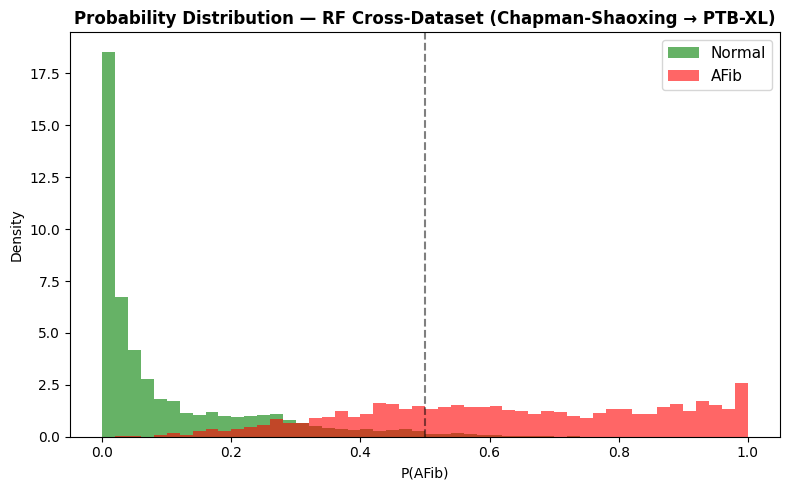

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(all_probs[all_targets==0], bins=50, range=(0,1), alpha=0.6, color='green', label='Normal', density=True)
ax.hist(all_probs[all_targets==1], bins=50, range=(0,1), alpha=0.6, color='red', label='AFib', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
ax.set_title("Probability Distribution — RF Cross-Dataset (Chapman-Shaoxing → PTB-XL)", fontsize=12, fontweight='bold')
ax.set_xlabel("P(AFib)"); ax.set_ylabel("Density"); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "ptbxl_rf_prob_dist.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 15. Final Summary

In [16]:
print("=" * 70)
print("CROSS-DATASET VALIDATION SUMMARY (Random Forest)")
print("=" * 70)
print()
print("Training: Chapman-Shaoxing (132 morphological features, 12 leads)")
print("Testing:  PTB-XL")
print(f"  Records: {len(all_labels)} (AFib: {loaded_afib}, Normal: {loaded_normal})")
print()
print(f"{'Metric':<15} {'Value':<10}")
print("-" * 25)
for name, val in [("Accuracy", acc), ("Precision", prec), ("Recall", rec),
                   ("F1", f1), ("MCC", mcc), ("AUROC", auroc), ("AUPRC", auprc),
                   ("Brier", brier), ("ECE", ece), ("MCE", mce)]:
    print(f"{name:<15} {val:.4f}")
print()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

print()
print("PDFs saved:")
for fn in sorted(os.listdir(config.pdf_dir)):
    if fn.endswith('.pdf'): print(f"  {fn}")

CROSS-DATASET VALIDATION SUMMARY (Random Forest)

Training: Chapman-Shaoxing (132 morphological features, 12 leads)
Testing:  PTB-XL
  Records: 10954 (AFib: 1477, Normal: 9477)

Metric          Value     
-------------------------
Accuracy        0.9400
Precision       0.8475
Recall          0.6770
F1              0.7527
MCC             0.7250
AUROC           0.9713
AUPRC           0.8623
Brier           0.0501
ECE             0.0615
MCE             0.2038

TN=9297  FP=180  FN=477  TP=1000

PDFs saved:
  ptbxl_rf_calibration.pdf
  ptbxl_rf_confusion_matrix.pdf
  ptbxl_rf_pr.pdf
  ptbxl_rf_prob_dist.pdf
  ptbxl_rf_roc.pdf


In [17]:
def print_high_confidence_errors(targets, preds, probs, label):
    confidence = np.maximum(probs, 1.0 - probs)
    errors = preds != targets
    total_errors = int(errors.sum())

    print(f"\n{label}")
    print(f"Total errors: {total_errors}")
    print(f"{'Threshold':<12}{'Errors':<10}{'FP':<8}{'FN':<8}{'% of errors':<12}")
    print('-' * 50)

    for threshold in [0.90, 0.95, 0.99]:
        mask = errors & (confidence >= threshold)
        fp = int(np.sum(mask & (targets == 0) & (preds == 1)))
        fn = int(np.sum(mask & (targets == 1) & (preds == 0)))
        n = int(mask.sum())
        pct = 100.0 * n / total_errors if total_errors else 0.0
        print(f">={threshold:.2f}       {n:<10}{fp:<8}{fn:<8}{pct:>8.1f}%")

print_high_confidence_errors(
    all_targets, all_preds, all_probs,
    "Random Forest - PTB-XL"
)



Random Forest - PTB-XL
Total errors: 657
Threshold   Errors    FP      FN      % of errors 
--------------------------------------------------
>=0.90       11        5       6            1.7%
>=0.95       4         2       2            0.6%
>=0.99       0         0       0            0.0%
